# Logistic Regression Model

This notebook reuses the same preprocessing logic from `preprocessing.ipynb` and follows a structure similar to `clustering_model.ipynb`, but it is designed for **logistic regression**.

The idea is:
- clean the raw data,
- engineer the same extra features,
- apply the same preprocessing pipeline,
- train a logistic regression classifier,
- evaluate predicted default probabilities,
- inspect which features push risk up or down.


## Why logistic regression is a strong baseline

Logistic regression is a very good first supervised model for credit risk because:

- it directly predicts the probability of default,
- it works well with tabular data,
- it is simple to explain,
- its coefficients are interpretable,
- it gives us a strong baseline before trying more complex models.

For a borrower with features `x`, logistic regression estimates:

`P(default = 1 | x)`

So unlike clustering, this model is trained using the real default labels from the start.


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    brier_score_loss,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


In [20]:
# Load the dataset
df = pd.read_csv("data/credit_risk_dataset.csv")
df = df.drop_duplicates().copy()

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (32416, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [21]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (25932, 11)
Test shape: (6484, 11)


In [22]:
# Reusing the same data cleaning logic from preprocessing.ipynb
def clean_invalid_rows(df):
    df = df.copy()
    df = df[(df["person_age"] > 0) & (df["person_age"] < 100)]
    df = df[df["person_income"] > 0]
    df = df[df["loan_amnt"] > 0]
    df = df[
        (df["person_emp_length"].isna())
        | ((df["person_emp_length"] >= 0) & (df["person_emp_length"] <= 50))
    ]
    df = df[
        (df["person_emp_length"].isna())
        | (df["person_emp_length"] <= df["person_age"])
    ]
    df = df[(df["loan_int_rate"].isna()) | (df["loan_int_rate"] > 0)]
    return df


X_train = clean_invalid_rows(X_train)
y_train = y_train.loc[X_train.index]

X_test = clean_invalid_rows(X_test)
y_test = y_test.loc[X_test.index]

print("Cleaned train shape:", X_train.shape)
print("Cleaned test shape:", X_test.shape)


Cleaned train shape: (25925, 11)
Cleaned test shape: (6484, 11)


In [23]:
# Reusing the same engineered features from preprocessing.ipynb
def add_engineered_features(df):
    df = df.copy()
    df["income_to_loan_ratio"] = df["person_income"] / df["loan_amnt"]
    df["emp_length_to_age_ratio"] = df["person_emp_length"] / df["person_age"]
    return df


X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)

display(X_train.head())


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_to_loan_ratio,emp_length_to_age_ratio
7173,23,75800,RENT,0.0,PERSONAL,A,7000,6.54,0.09,N,2,10.828571,0.000000
16396,25,61959,RENT,9.0,EDUCATION,C,25000,12.73,0.40,Y,4,2.478360,0.360000
21744,31,53088,RENT,0.0,PERSONAL,A,6000,6.54,0.11,N,9,8.848000,0.000000
27805,27,228000,MORTGAGE,12.0,HOMEIMPROVEMENT,A,6000,7.14,0.03,N,6,38.000000,0.444444
24563,29,54000,RENT,0.0,PERSONAL,D,10000,14.96,0.19,N,9,5.400000,0.000000


In [24]:
# Reusing the same preprocessing pipeline from preprocessing.ipynb
categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

log_features = ["person_income", "loan_amnt", "income_to_loan_ratio"]

numeric_features = [
    "person_age",
    "person_emp_length",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "emp_length_to_age_ratio"
]

log_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("log_num", log_transformer, log_features),
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("Number of engineered/preprocessed features:", len(feature_names))


Processed train shape: (25925, 28)
Processed test shape: (6484, 28)
Number of engineered/preprocessed features: 28


## Fit the logistic regression model

We use a supervised classifier now, so the model directly learns from `loan_status`.

A balanced class weight is helpful here because defaults are less common than non-defaults.


In [25]:
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train_processed, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [26]:
# Predict class labels
y_train_pred = log_model.predict(X_train_processed)
y_test_pred = log_model.predict(X_test_processed)

# Predict probabilities for default = 1
y_train_proba = log_model.predict_proba(X_train_processed)[:, 1]
y_test_proba = log_model.predict_proba(X_test_processed)[:, 1]


In [27]:
print("Train Accuracy:", round(accuracy_score(y_train, y_train_pred), 4))
print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Test ROC-AUC:", round(roc_auc_score(y_test, y_test_proba), 4))
print("Test Brier Score:", round(brier_score_loss(y_test, y_test_proba), 4))

Train Accuracy: 0.8196
Test Accuracy: 0.8199
Confusion Matrix:
[[4203  863]
 [ 305 1113]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      5066
           1       0.56      0.78      0.66      1418

    accuracy                           0.82      6484
   macro avg       0.75      0.81      0.77      6484
weighted avg       0.85      0.82      0.83      6484

Test ROC-AUC: 0.8778
Test Brier Score: 0.1334


In [28]:
evaluation_summary = pd.DataFrame({
    "metric": ["train_accuracy", "test_accuracy", "roc_auc", "brier_score"],
    "value": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_proba),
        brier_score_loss(y_test, y_test_proba)
    ]
})

display(evaluation_summary)


,metric,value
0,train_accuracy,0.819595
1,test_accuracy,0.819864
2,roc_auc,0.877772
3,brier_score,0.133393


In [29]:
# Look at a few example predictions
prediction_examples = X_test.copy().reset_index(drop=True)
prediction_examples["actual_default"] = y_test.reset_index(drop=True)
prediction_examples["predicted_default_probability"] = y_test_proba
prediction_examples["predicted_class"] = y_test_pred

display(
    prediction_examples[
        [
            "person_income",
            "loan_amnt",
            "loan_int_rate",
            "loan_percent_income",
            "loan_grade",
            "actual_default",
            "predicted_default_probability",
            "predicted_class"
        ]
    ].head(15)
)


,person_income,loan_amnt,loan_int_rate,loan_percent_income,loan_grade,actual_default,predicted_default_probability,predicted_class
0,56461,5400,15.68,0.10,E,0,0.818919,1
1,108000,4925,NaN,0.05,B,1,0.113349,0
2,102000,18000,9.33,0.18,B,0,0.022191,0
3,45000,10000,12.42,0.22,B,0,0.308414,0
4,30000,12000,10.39,0.40,B,1,0.924363,1
5,113000,9600,NaN,0.08,C,0,0.173603,0
6,73000,16000,19.41,0.22,F,1,0.927735,1
7,90000,7500,15.58,0.08,D,0,0.531793,1
8,135000,24250,12.87,0.18,C,0,0.231258,0
9,52000,8000,7.51,0.15,A,0,0.204169,0


## Interpret the model coefficients

Because logistic regression is linear in the transformed feature space, each coefficient tells us the direction of the effect:

- **positive coefficient** → pushes the prediction toward default,
- **negative coefficient** → pushes the prediction away from default.

The magnitude shows how strong that effect is after preprocessing.


In [30]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": log_model.coef_[0]
}).sort_values("coefficient", ascending=False)

display(coef_df.head(15))


,feature,coefficient
25,cat__loan_grade_G,3.188013
2,log_num__income_to_loan_ratio,2.526119
1,log_num__loan_amnt,1.929757
6,num__loan_percent_income,1.269576
24,cat__loan_grade_F,1.154966
12,cat__person_home_ownership_RENT,0.830108
23,cat__loan_grade_E,0.804348
15,cat__loan_intent_HOMEIMPROVEMENT,0.681813
10,cat__person_home_ownership_OTHER,0.639303
22,cat__loan_grade_D,0.520963


In [31]:
display(coef_df.tail(15).sort_values("coefficient"))

,feature,coefficient
0,log_num__person_income,-2.246476
19,cat__loan_grade_A,-2.095366
20,cat__loan_grade_B,-1.842138
11,cat__person_home_ownership_OWN,-1.568825
21,cat__loan_grade_C,-1.565661
18,cat__loan_intent_VENTURE,-0.705943
14,cat__loan_intent_EDUCATION,-0.274384
17,cat__loan_intent_PERSONAL,-0.136713
4,num__person_emp_length,-0.093897
7,num__cb_person_cred_hist_length,-0.029429


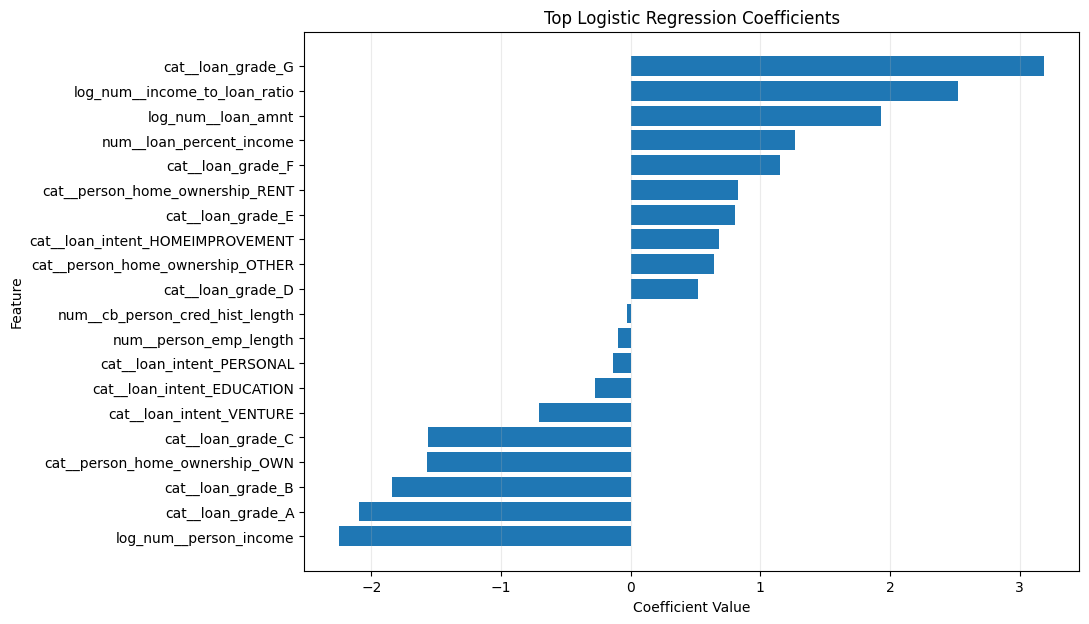

In [32]:
# Plot the most important positive and negative coefficients
plot_df = pd.concat([
    coef_df.head(10),
    coef_df.tail(10)
]).sort_values("coefficient")

plt.figure(figsize=(10, 7))
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.25)
plt.show()


## Extra evaluation plots

These plots help us see how well the predicted probabilities separate defaulters from non-defaulters.

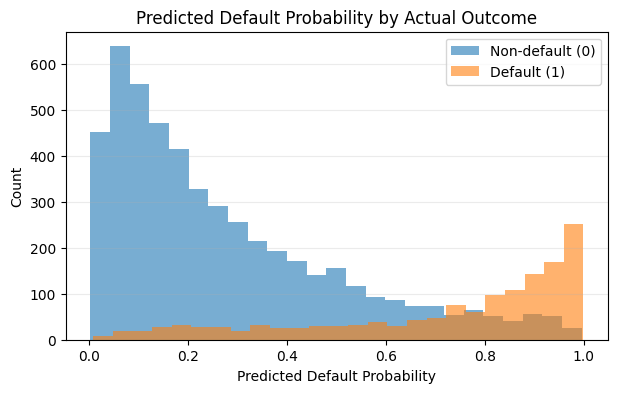

In [33]:
plt.figure(figsize=(7, 4))
plt.hist(
    y_test_proba[y_test.to_numpy() == 0],
    bins=25,
    alpha=0.6,
    label="Non-default (0)"
)
plt.hist(
    y_test_proba[y_test.to_numpy() == 1],
    bins=25,
    alpha=0.6,
    label="Default (1)"
)
plt.title("Predicted Default Probability by Actual Outcome")
plt.xlabel("Predicted Default Probability")
plt.ylabel("Count")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


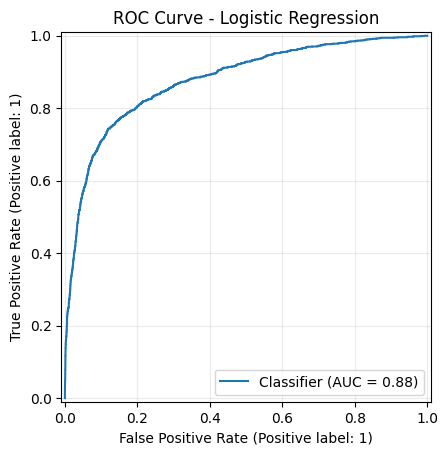

In [34]:
RocCurveDisplay.from_predictions(y_test, y_test_proba)
plt.title("ROC Curve - Logistic Regression")
plt.grid(alpha=0.25)
plt.show()


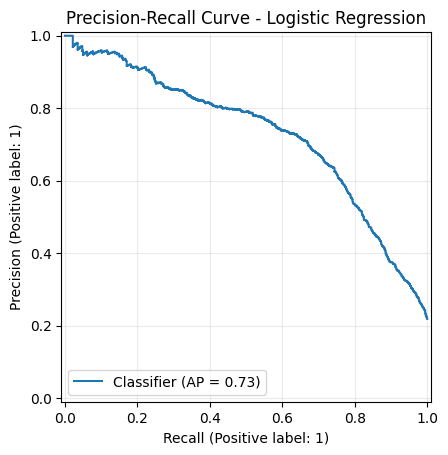

In [35]:
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba)
plt.title("Precision-Recall Curve - Logistic Regression")
plt.grid(alpha=0.25)
plt.show()


## What We Learned

This logistic regression model is a much more natural fit for this problem than clustering because it is a supervised method. It directly learns from the default labels instead of trying to infer risk indirectly from groups.

The ROC-AUC tells us how well the model ranks risky borrowers above safer borrowers. A score clearly above `0.5` means the model is doing useful ranking, and a score close to `1.0` would mean excellent separation.

The Brier score tells us whether the predicted probabilities are close to the real outcomes. Lower is better. This is especially important in credit risk because we often care about probability quality, not only about the final yes/no decision.

Another strong advantage of logistic regression is interpretability. By looking at the coefficients, we can see which transformed features increase predicted risk and which ones reduce it. That makes the model easier to explain in a report and easier to compare against more complex methods later.
